In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import ta
import pandas_ta as pta

# Load data
AMZN_path = "C:/Users/yhsol/Downloads/AMZN_alpha_1min_2024-05_to_2025-05 (1).csv"
df = pd.read_csv(AMZN_path)

df['timestamp'] = pd.to_datetime(df['Timestamp'])
df.sort_values('timestamp', inplace=True)
df.set_index('timestamp', inplace=True)
df.drop(columns=['Timestamp'], inplace=True, errors='ignore')
df = df.between_time('09:30', '16:00')

# PSAR
df['PSAR'] = ta.trend.PSARIndicator(df['High'], df['Low'], df['Close'], step=0.02, max_step=0.2).psar()

# STD (Standard Deviation)
std_length = 20
df['STD'] = df['Close'].rolling(window=std_length).std()

# RCI
def rci(series, period=14):
    result = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        price = series[i - period + 1:i + 1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff ** 2)) / (period * (period ** 2 - 1))) * 100
        result[i] = rci_value
    return result

df['RCI_14'] = rci(df['Close'], period=14)

# Ichimoku
ichi = ta.trend.IchimokuIndicator(df['High'], df['Low'], window1=9, window2=26, window3=52, visual=False)
df['Tenkan_Sen'] = ichi.ichimoku_conversion_line()
df['Kijun_Sen'] = ichi.ichimoku_base_line()
df['Senkou_Span_A'] = ichi.ichimoku_a()
df['Senkou_Span_B'] = ichi.ichimoku_b()
df['Chikou_Span'] = df['Close'].shift(26)

# AO (Awesome Oscillator)
median_price = (df['High'] + df['Low']) / 2
df['AO'] = median_price.rolling(window=5).mean() - median_price.rolling(window=34).mean()

# CMF (Chaikin Money Flow)
def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

df['CMF'] = chaikin_money_flow(df, window=20)

# ADX
adx = ta.trend.ADXIndicator(df['High'], df['Low'], df['Close'], window=14)
df['ADX'] = adx.adx()

# Envelope Upper
sma_length = 20
df['SMA'] = df['Close'].rolling(window=sma_length).mean()
df['Upper_Envelope'] = df['SMA'] * (1 + 0.02)

# Williams %R
df['WilliamsR'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'], lbp=14, fillna=True)

# Stochastic Oscillator %K
df['Stoch_K'] = ta.momentum.stoch(df['High'], df['Low'], df['Close'], window=14, smooth_window=3, fillna=True)

# Drop missing
df.dropna(inplace=True)

# Target (Direction)
noise_thresh = 0.0001
df['Return'] = df['Close'].pct_change().shift(-1)
df['Direction'] = np.where(df['Return'] > noise_thresh, 1,
                    np.where(df['Return'] < -noise_thresh, 0, np.nan))
df.dropna(subset=['Direction'], inplace=True)
df['Direction'] = df['Direction'].astype(int)

# Features for model
feature_cols = [
    'STD', 'RCI_14',
    'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span',
    'AO', 'CMF', 'ADX', 'Upper_Envelope',
    'WilliamsR', 'Stoch_K', 'PSAR'
]
X = df[feature_cols]
y = df['Direction']

# Train-test split
split_index = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
returns_test = df['Return'].iloc[split_index:]

# XGBoost + Random Search
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    booster='gbtree',
    tree_method='exact',
    predictor='cpu_predictor',
    use_label_encoder=False,
    random_state=42
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='accuracy',
    cv=3,
    verbose=0,
    n_jobs=8,
    error_score='raise'
)

search.fit(X_train, y_train)

# Evaluation
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best Parameters: {search.best_params_}")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
import joblib

# Save the best model to a file
joblib.dump(search.best_estimator_, "xgb_amzn_best_model.pkl")
print("Model saved to 'xgb_amzn_best_model.pkl'")


c:\Users\yhsol\anaconda3\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
c:\Users\yhsol\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:32:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 1.0}

Accuracy: 0.5262

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.39      0.45     12362
           1       0.52      0.66      0.58     12449

    accuracy                           0.53     24811
   macro avg       0.53      0.53      0.52     24811
weighted avg       0.53      0.53      0.52     24811

Confusion Matrix:
 [[4785 7577]
 [4178 8271]]
Model saved to 'xgb_amzn_best_model.pkl'


Model loaded successfully.


c:\Users\yhsol\anaconda3\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


META Model Evaluation:
Accuracy: 0.5056

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.08      0.15     41615
           1       0.51      0.92      0.65     42342

    accuracy                           0.51     83957
   macro avg       0.51      0.50      0.40     83957
weighted avg       0.51      0.51      0.40     83957

Confusion Matrix:
 [[ 3531 38084]
 [ 3428 38914]]

📈 Buy & Hold Cumulative Return:     1.3600
🤖 Strategy Return (No Fees):        1.2689
💸 Strategy Return (With Fees):      0.6126
🔄 Number of Trades Executed:        7282


C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\930923096.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cum_buy_hold = np.exp(meta_df['Return'].cumsum())[-1]
C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\930923096.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cum_strategy = np.exp(meta_df['Strategy_Return'].cumsum())[-1]
C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\930923096.py:109: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

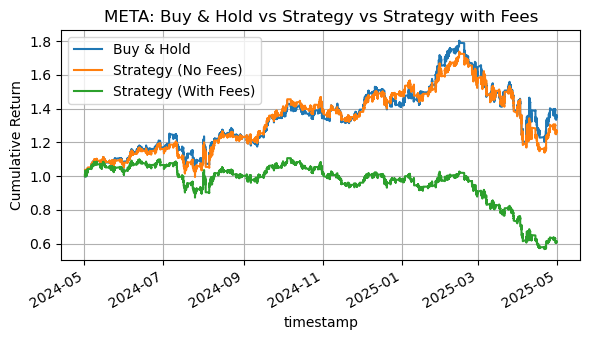

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ta
import joblib

# === Load saved model ===
best_model = joblib.load("xgb_amzn_best_model.pkl")
print("Model loaded successfully.")

# === Load META Data ===
META_path = "C:/Users/yhsol/Downloads/META_alpha_1min_2024-05_to_2025-05.csv"
meta_df = pd.read_csv(META_path)

meta_df['timestamp'] = pd.to_datetime(meta_df['timestamp'])
meta_df.sort_values('timestamp', inplace=True)
meta_df.set_index('timestamp', inplace=True)
meta_df.drop(columns=['Timestamp'], inplace=True, errors='ignore')
meta_df = meta_df.between_time('09:30', '16:00')

# === Feature Engineering ===
meta_df['PSAR'] = ta.trend.PSARIndicator(meta_df['High'], meta_df['Low'], meta_df['Close']).psar()
meta_df['STD'] = meta_df['Close'].rolling(window=20).std()

def rci(series, period=14):
    result = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        price = series[i - period + 1:i + 1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff ** 2)) / (period * (period ** 2 - 1))) * 100
        result[i] = rci_value
    return result

meta_df['RCI_14'] = rci(meta_df['Close'], period=14)

ichi = ta.trend.IchimokuIndicator(meta_df['High'], meta_df['Low'], window1=9, window2=26, window3=52, visual=False)
meta_df['Tenkan_Sen'] = ichi.ichimoku_conversion_line()
meta_df['Kijun_Sen'] = ichi.ichimoku_base_line()
meta_df['Senkou_Span_A'] = ichi.ichimoku_a()
meta_df['Senkou_Span_B'] = ichi.ichimoku_b()
meta_df['Chikou_Span'] = meta_df['Close'].shift(26)

median_price = (meta_df['High'] + meta_df['Low']) / 2
meta_df['AO'] = median_price.rolling(window=5).mean() - median_price.rolling(window=34).mean()

def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

meta_df['CMF'] = chaikin_money_flow(meta_df, window=20)

adx = ta.trend.ADXIndicator(meta_df['High'], meta_df['Low'], meta_df['Close'], window=14)
meta_df['ADX'] = adx.adx()

meta_df['SMA'] = meta_df['Close'].rolling(window=20).mean()
meta_df['Upper_Envelope'] = meta_df['SMA'] * (1 + 0.02)

meta_df['WilliamsR'] = ta.momentum.williams_r(meta_df['High'], meta_df['Low'], meta_df['Close'], lbp=14, fillna=True)
meta_df['Stoch_K'] = ta.momentum.stoch(meta_df['High'], meta_df['Low'], meta_df['Close'], window=14, smooth_window=3, fillna=True)

meta_df.dropna(inplace=True)

noise_thresh = 0.0001
meta_df['Return'] = meta_df['Close'].pct_change().shift(-1)
meta_df['Direction'] = np.where(meta_df['Return'] > noise_thresh, 1,
                        np.where(meta_df['Return'] < -noise_thresh, 0, np.nan))
meta_df.dropna(subset=['Direction'], inplace=True)
meta_df['Direction'] = meta_df['Direction'].astype(int)

# === Predict ===
feature_cols = [
    'STD', 'RCI_14',
    'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span',
    'AO', 'CMF', 'ADX', 'Upper_Envelope',
    'WilliamsR', 'Stoch_K', 'PSAR'
]

X_meta = meta_df[feature_cols]
y_meta = meta_df['Direction']
y_meta_pred = best_model.predict(X_meta)

# === Evaluation ===
print("META Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_meta, y_meta_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_meta, y_meta_pred))
print("Confusion Matrix:\n", confusion_matrix(y_meta, y_meta_pred))

# === Backtesting with fees ===
meta_df = meta_df.iloc[-len(y_meta_pred):].copy()
meta_df['Predicted'] = y_meta_pred
meta_df['Signal'] = meta_df['Predicted'].shift(1)
meta_df['Strategy_Return'] = meta_df['Return'] * (meta_df['Signal'] == 1)

# Fee calculation
fee_per_trade = 0.0001  # 0.01%
meta_df['Trade'] = (meta_df['Signal'] != meta_df['Signal'].shift(1)).astype(int)
meta_df['Cumulative_Trades'] = meta_df['Trade'].cumsum()
meta_df['Cumulative_Fees'] = meta_df['Trade'] * fee_per_trade
meta_df['Cumulative_Fee_Adjustment'] = meta_df['Cumulative_Fees'].cumsum()
meta_df['Strategy_Return_Fee_Adjusted'] = meta_df['Strategy_Return'] - (meta_df['Trade'] * fee_per_trade)

# Cumulative returns
cum_buy_hold = np.exp(meta_df['Return'].cumsum())[-1]
cum_strategy = np.exp(meta_df['Strategy_Return'].cumsum())[-1]
cum_strategy_fee = np.exp(meta_df['Strategy_Return_Fee_Adjusted'].cumsum())[-1]
total_trades = int(meta_df['Trade'].sum())

# === Results Summary ===
print(f"\n📈 Buy & Hold Cumulative Return:     {cum_buy_hold:.4f}")
print(f"🤖 Strategy Return (No Fees):        {cum_strategy:.4f}")
print(f"💸 Strategy Return (With Fees):      {cum_strategy_fee:.4f}")
print(f"🔄 Number of Trades Executed:        {total_trades}")

# === Plot ===
plt.figure(figsize=(6, 3.5))
(meta_df['Return'].cumsum().apply(np.exp)).plot(label="Buy & Hold")
(meta_df['Strategy_Return'].cumsum().apply(np.exp)).plot(label="Strategy (No Fees)")
(meta_df['Strategy_Return_Fee_Adjusted'].cumsum().apply(np.exp)).plot(label="Strategy (With Fees)")
plt.title("META: Buy & Hold vs Strategy vs Strategy with Fees")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Model loaded successfully.


c:\Users\yhsol\anaconda3\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


MSFT Model Evaluation:
Accuracy: 0.5078

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.07      0.12     41764
           1       0.51      0.94      0.66     42704

    accuracy                           0.51     84468
   macro avg       0.51      0.50      0.39     84468
weighted avg       0.51      0.51      0.39     84468

Confusion Matrix:
 [[ 2756 39008]
 [ 2567 40137]]

📈 Buy & Hold Cumulative Return:     0.9555
🤖 Strategy Return (No Fees):        0.8728
💸 Strategy Return (With Fees):      0.4742
🔄 Number of Trades Executed:        6100


C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\1625152212.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cum_buy_hold = np.exp(msft_df['Return'].cumsum())[-1]
C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\1625152212.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cum_strategy = np.exp(msft_df['Strategy_Return'].cumsum())[-1]
C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\1625152212.py:109: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positi

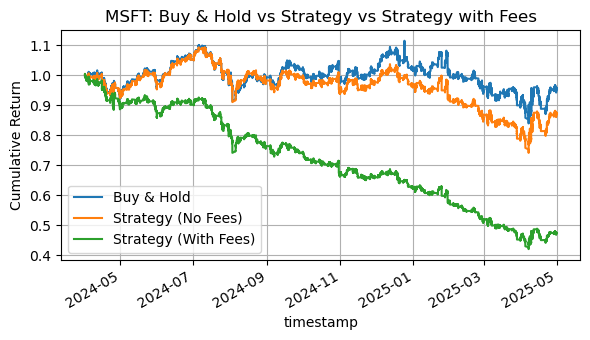

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ta
import joblib

# === Load trained model ===
best_model = joblib.load("xgb_amzn_best_model.pkl")
print("Model loaded successfully.")

# === Load MSFT Data ===
MSFT_path = r"C:\Users\yhsol\Downloads\MSFT_Combined_1min_2024_to_2025.csv"
msft_df = pd.read_csv(MSFT_path)

msft_df['timestamp'] = pd.to_datetime(msft_df['Timestamp'])
msft_df.sort_values('timestamp', inplace=True)
msft_df.set_index('timestamp', inplace=True)
msft_df.drop(columns=['Timestamp'], inplace=True, errors='ignore')
msft_df = msft_df.between_time('09:30', '16:00')

# === Feature Engineering ===
msft_df['PSAR'] = ta.trend.PSARIndicator(msft_df['High'], msft_df['Low'], msft_df['Close']).psar()
msft_df['STD'] = msft_df['Close'].rolling(window=20).std()

def rci(series, period=14):
    result = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        price = series[i - period + 1:i + 1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff ** 2)) / (period * (period ** 2 - 1))) * 100
        result[i] = rci_value
    return result

msft_df['RCI_14'] = rci(msft_df['Close'], period=14)

ichi = ta.trend.IchimokuIndicator(msft_df['High'], msft_df['Low'], window1=9, window2=26, window3=52, visual=False)
msft_df['Tenkan_Sen'] = ichi.ichimoku_conversion_line()
msft_df['Kijun_Sen'] = ichi.ichimoku_base_line()
msft_df['Senkou_Span_A'] = ichi.ichimoku_a()
msft_df['Senkou_Span_B'] = ichi.ichimoku_b()
msft_df['Chikou_Span'] = msft_df['Close'].shift(26)

median_price = (msft_df['High'] + msft_df['Low']) / 2
msft_df['AO'] = median_price.rolling(window=5).mean() - median_price.rolling(window=34).mean()

def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

msft_df['CMF'] = chaikin_money_flow(msft_df, window=20)

adx = ta.trend.ADXIndicator(msft_df['High'], msft_df['Low'], msft_df['Close'], window=14)
msft_df['ADX'] = adx.adx()

msft_df['SMA'] = msft_df['Close'].rolling(window=20).mean()
msft_df['Upper_Envelope'] = msft_df['SMA'] * (1 + 0.02)

msft_df['WilliamsR'] = ta.momentum.williams_r(msft_df['High'], msft_df['Low'], msft_df['Close'], lbp=14, fillna=True)
msft_df['Stoch_K'] = ta.momentum.stoch(msft_df['High'], msft_df['Low'], msft_df['Close'], window=14, smooth_window=3, fillna=True)

msft_df.dropna(inplace=True)

noise_thresh = 0.0001
msft_df['Return'] = msft_df['Close'].pct_change().shift(-1)
msft_df['Direction'] = np.where(msft_df['Return'] > noise_thresh, 1,
                        np.where(msft_df['Return'] < -noise_thresh, 0, np.nan))
msft_df.dropna(subset=['Direction'], inplace=True)
msft_df['Direction'] = msft_df['Direction'].astype(int)

# === Prepare Features and Predict ===
feature_cols = [
    'STD', 'RCI_14',
    'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span',
    'AO', 'CMF', 'ADX', 'Upper_Envelope',
    'WilliamsR', 'Stoch_K', 'PSAR'
]

X_msft = msft_df[feature_cols]
y_msft = msft_df['Direction']
y_msft_pred = best_model.predict(X_msft)

# === Evaluation ===
print("MSFT Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_msft, y_msft_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_msft, y_msft_pred))
print("Confusion Matrix:\n", confusion_matrix(y_msft, y_msft_pred))

# === Backtest with and without fees ===
msft_df = msft_df.iloc[-len(y_msft_pred):].copy()
msft_df['Predicted'] = y_msft_pred
msft_df['Signal'] = msft_df['Predicted'].shift(1)
msft_df['Strategy_Return'] = msft_df['Return'] * (msft_df['Signal'] == 1)

# Add trading fees
fee_per_trade = 0.0001  # 0.01%
msft_df['Trade'] = (msft_df['Signal'] != msft_df['Signal'].shift(1)).astype(int)
msft_df['Cumulative_Trades'] = msft_df['Trade'].cumsum()
msft_df['Cumulative_Fees'] = msft_df['Trade'] * fee_per_trade
msft_df['Cumulative_Fee_Adjustment'] = msft_df['Cumulative_Fees'].cumsum()
msft_df['Strategy_Return_Fee_Adjusted'] = msft_df['Strategy_Return'] - (msft_df['Trade'] * fee_per_trade)

# === Return Summary ===
cum_buy_hold = np.exp(msft_df['Return'].cumsum())[-1]
cum_strategy = np.exp(msft_df['Strategy_Return'].cumsum())[-1]
cum_strategy_fee = np.exp(msft_df['Strategy_Return_Fee_Adjusted'].cumsum())[-1]
total_trades = int(msft_df['Trade'].sum())

print(f"\n📈 Buy & Hold Cumulative Return:     {cum_buy_hold:.4f}")
print(f"🤖 Strategy Return (No Fees):        {cum_strategy:.4f}")
print(f"💸 Strategy Return (With Fees):      {cum_strategy_fee:.4f}")
print(f"🔄 Number of Trades Executed:        {total_trades}")

# === Plot ===
plt.figure(figsize=(6, 3.5))
(msft_df['Return'].cumsum().apply(np.exp)).plot(label="Buy & Hold")
(msft_df['Strategy_Return'].cumsum().apply(np.exp)).plot(label="Strategy (No Fees)")
(msft_df['Strategy_Return_Fee_Adjusted'].cumsum().apply(np.exp)).plot(label="Strategy (With Fees)")
plt.title("MSFT: Buy & Hold vs Strategy vs Strategy with Fees")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Model loaded successfully.


c:\Users\yhsol\anaconda3\Lib\site-packages\ta\trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


NVIDIA Model Evaluation:
Accuracy: 0.5039

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.58      0.54     47780
           1       0.51      0.43      0.46     48572

    accuracy                           0.50     96352
   macro avg       0.50      0.50      0.50     96352
weighted avg       0.50      0.50      0.50     96352

Confusion Matrix:
 [[27905 19875]
 [27928 20644]]

📈 Buy & Hold Cumulative Return:     1.4057
🤖 Strategy Return (No Fees):        1.1854
💸 Strategy Return (With Fees):      0.2318
🔄 Number of Trades Executed:        16322


C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\772450971.py:105: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cum_buy_hold = np.exp(nvda_df['Return'].cumsum())[-1]
C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\772450971.py:106: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cum_strategy = np.exp(nvda_df['Strategy_Return'].cumsum())[-1]
C:\Users\yhsol\AppData\Local\Temp\ipykernel_29260\772450971.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position,

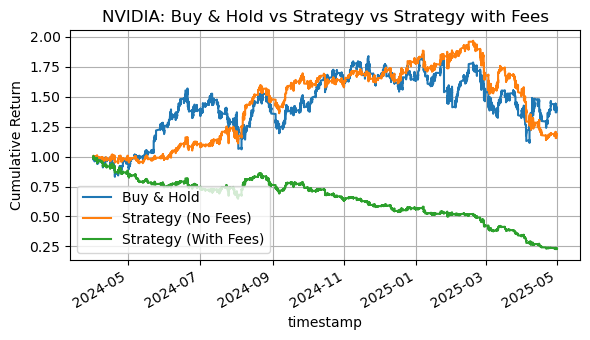

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ta
import joblib

# === Load trained model ===
best_model = joblib.load("xgb_amzn_best_model.pkl")
print("Model loaded successfully.")

# === Load NVIDIA Data ===
NVDA_path = r"C:\Users\yhsol\Downloads\NVID_Combined_1min_2019_to_2025.csv"
nvda_df = pd.read_csv(NVDA_path)

nvda_df['timestamp'] = pd.to_datetime(nvda_df['timestamp'])
nvda_df.sort_values('timestamp', inplace=True)
nvda_df.set_index('timestamp', inplace=True)
nvda_df.drop(columns=['Timestamp'], inplace=True, errors='ignore')
nvda_df = nvda_df.between_time('09:30', '16:00')

# === Feature Engineering ===
nvda_df['PSAR'] = ta.trend.PSARIndicator(nvda_df['High'], nvda_df['Low'], nvda_df['Close']).psar()
nvda_df['STD'] = nvda_df['Close'].rolling(window=20).std()

def rci(series, period=14):
    result = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        price = series[i - period + 1:i + 1].to_numpy()
        time = np.arange(period, 0, -1)
        order = price.argsort().argsort() + 1
        diff = order - time
        rci_value = (1 - (6 * np.sum(diff ** 2)) / (period * (period ** 2 - 1))) * 100
        result[i] = rci_value
    return result

nvda_df['RCI_14'] = rci(nvda_df['Close'], period=14)

ichi = ta.trend.IchimokuIndicator(nvda_df['High'], nvda_df['Low'], window1=9, window2=26, window3=52, visual=False)
nvda_df['Tenkan_Sen'] = ichi.ichimoku_conversion_line()
nvda_df['Kijun_Sen'] = ichi.ichimoku_base_line()
nvda_df['Senkou_Span_A'] = ichi.ichimoku_a()
nvda_df['Senkou_Span_B'] = ichi.ichimoku_b()
nvda_df['Chikou_Span'] = nvda_df['Close'].shift(26)

median_price = (nvda_df['High'] + nvda_df['Low']) / 2
nvda_df['AO'] = median_price.rolling(window=5).mean() - median_price.rolling(window=34).mean()

def chaikin_money_flow(df, window=20):
    mfv = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low']) * df['Volume']
    cmf = mfv.rolling(window=window).sum() / df['Volume'].rolling(window=window).sum()
    return cmf

nvda_df['CMF'] = chaikin_money_flow(nvda_df, window=20)

adx = ta.trend.ADXIndicator(nvda_df['High'], nvda_df['Low'], nvda_df['Close'], window=14)
nvda_df['ADX'] = adx.adx()

nvda_df['SMA'] = nvda_df['Close'].rolling(window=20).mean()
nvda_df['Upper_Envelope'] = nvda_df['SMA'] * (1 + 0.02)

nvda_df['WilliamsR'] = ta.momentum.williams_r(nvda_df['High'], nvda_df['Low'], nvda_df['Close'], lbp=14, fillna=True)
nvda_df['Stoch_K'] = ta.momentum.stoch(nvda_df['High'], nvda_df['Low'], nvda_df['Close'], window=14, smooth_window=3, fillna=True)

nvda_df.dropna(inplace=True)

noise_thresh = 0.0001
nvda_df['Return'] = nvda_df['Close'].pct_change().shift(-1)
nvda_df['Direction'] = np.where(nvda_df['Return'] > noise_thresh, 1,
                        np.where(nvda_df['Return'] < -noise_thresh, 0, np.nan))
nvda_df.dropna(subset=['Direction'], inplace=True)
nvda_df['Direction'] = nvda_df['Direction'].astype(int)

# === Prepare features ===
feature_cols = [
    'STD', 'RCI_14',
    'Tenkan_Sen', 'Kijun_Sen', 'Senkou_Span_A', 'Senkou_Span_B', 'Chikou_Span',
    'AO', 'CMF', 'ADX', 'Upper_Envelope',
    'WilliamsR', 'Stoch_K', 'PSAR'
]

X_nvda = nvda_df[feature_cols]
y_nvda = nvda_df['Direction']
y_nvda_pred = best_model.predict(X_nvda)

# === Evaluation ===
print("NVIDIA Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_nvda, y_nvda_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_nvda, y_nvda_pred))
print("Confusion Matrix:\n", confusion_matrix(y_nvda, y_nvda_pred))

# === Backtest with/without fees ===
nvda_df = nvda_df.iloc[-len(y_nvda_pred):].copy()
nvda_df['Predicted'] = y_nvda_pred
nvda_df['Signal'] = nvda_df['Predicted'].shift(1)
nvda_df['Strategy_Return'] = nvda_df['Return'] * (nvda_df['Signal'] == 1)

fee_per_trade = 0.0001
nvda_df['Trade'] = (nvda_df['Signal'] != nvda_df['Signal'].shift(1)).astype(int)
nvda_df['Cumulative_Trades'] = nvda_df['Trade'].cumsum()
nvda_df['Cumulative_Fees'] = nvda_df['Trade'] * fee_per_trade
nvda_df['Cumulative_Fee_Adjustment'] = nvda_df['Cumulative_Fees'].cumsum()
nvda_df['Strategy_Return_Fee_Adjusted'] = nvda_df['Strategy_Return'] - (nvda_df['Trade'] * fee_per_trade)

cum_buy_hold = np.exp(nvda_df['Return'].cumsum())[-1]
cum_strategy = np.exp(nvda_df['Strategy_Return'].cumsum())[-1]
cum_strategy_fee = np.exp(nvda_df['Strategy_Return_Fee_Adjusted'].cumsum())[-1]
total_trades = int(nvda_df['Trade'].sum())

# === Results Summary ===
print(f"\n📈 Buy & Hold Cumulative Return:     {cum_buy_hold:.4f}")
print(f"🤖 Strategy Return (No Fees):        {cum_strategy:.4f}")
print(f"💸 Strategy Return (With Fees):      {cum_strategy_fee:.4f}")
print(f"🔄 Number of Trades Executed:        {total_trades}")

# === Plot ===
plt.figure(figsize=(6, 3.5))
(nvda_df['Return'].cumsum().apply(np.exp)).plot(label="Buy & Hold")
(nvda_df['Strategy_Return'].cumsum().apply(np.exp)).plot(label="Strategy (No Fees)")
(nvda_df['Strategy_Return_Fee_Adjusted'].cumsum().apply(np.exp)).plot(label="Strategy (With Fees)")
plt.title("NVIDIA: Buy & Hold vs Strategy vs Strategy with Fees")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
